# Análisis Exploratorio de Datos: Titanic

En esta actividad usaremos la base de datos de pasajeros del Titanic para practicar **análisis exploratorio de datos (EDA)**.

El objetivo no es hacer la mayor cantidad posible de gráficos, sino aprender a **usar los datos para responder preguntas**.

## Pregunta de investigación

> **¿Qué características de los pasajeros estaban asociadas con la supervivencia en el Titanic?**


## Librerías de visualización
### Matplotlib

Matplotlib tiene dos métodos para crear una figura, uno directo y otro enfocado a objetos.
Algunos links de interés:

- Argumentos que reciben matplotlib: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html
- Más opciones de gráficos en https://matplotlib.org/2.0.2/gallery.html
- Para una lista de colores disponibles en Matplotlib, https://matplotlib.org/stable/gallery/color/named_colors.html
- Explicación de plt y ax https://towardsdatascience.com/what-are-the-plt-and-ax-in-matplotlib-exactly-d2cf4bf164a9


### Seaborn
Proporciona una interfaz de alto nivel para dibujar gráficos estadísticos atractivos e informativos. A diferencia de Matplotlib, ésta no viene por defecto en Pandas.
Galería de gráficos: https://seaborn.pydata.org/examples/index.html

Otro link útil para visualizaciones en Python: https://python-graph-gallery.com/


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_style("white")


## Carga de los datos

Cada fila de la base de datos corresponde a **un pasajero**.

Las principales características disponibles son:

- `Survived`: supervivencia, 0 = no, 1 = sí
- `Pclass`: clase del pasajero, 1 = primera, 2 = segunda, 3 = tercera
- `Sex`: sexo
- `Age`: edad
- `SibSp`: número de hermanos/as o cónyuges a bordo
- `Parch`: número de padres o hijos a bordo
- `Ticket`: identificador del pasaje
- `Fare`: tarifa pagada
- `Cabin`: cabina
- `Embarked`: puerto de embarque, C = Cherbourg, Q = Queenstown, S = Southampton


In [2]:
titanic = pd.read_csv("titanic_semana_02.csv")
titanic.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#### **¿Cuáles variables son numéricas y cuáles son categoricas?**



Los datos numericos corresponden a al Edad, SibsP (hermanos), Fare (tarifa),Parch (Padres/Hijos).

Por otro lado las variables categoricas que "categorizan" a los pasajeros (instancias) serían: Survived (0 o 1), Pclass (Clase), Sex (Mujer o Hombre), Embarked (Donde subieron). El resto como Nombre, Ticket, Id o Cabina, al ser identificadores de cada pasajero también deben ser categoricos.

# Parte 1: Comprender la muestra

## ¿Quiénes eran los pasajeros del Titanic?

Antes de estudiar la supervivencia, necesitamos comprender a quiénes representan los datos.

Preguntas iniciales:

- ¿Cuántos pasajeros hay?
- ¿Qué características contiene la base de datos?
- ¿Cómo se distribuyen por sexo y clase?
- ¿Qué edades aparecen?
- ¿Cuánto pagaron por sus pasajes?
- ¿Viajaban solos o acompañados?
- ¿Desde qué puerto embarcaron?

Revise la estructura general de la tabla: dimensión, columnas, estadística básica, etc.

### Ejemplo de gráfico: pasajeros por sexo

Para una característica categórica podemos comenzar contando cuántos pasajeros pertenecen a cada grupo.


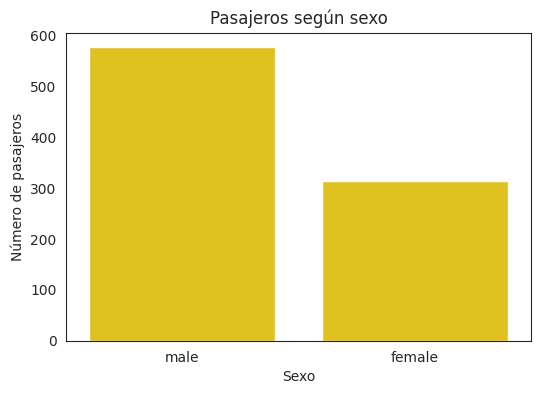

In [3]:
plt.figure(figsize=(6,4))

sns.countplot(data=titanic, x="Sex", color="gold")

plt.xlabel("Sexo")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según sexo")

plt.show()


### Ahora usted

**1. Grafique la cantidad de pasajeros según `Pclass`.**

- Qué clase contiene más pasajeros?
- La muestra está balanceada entre las tres clases?


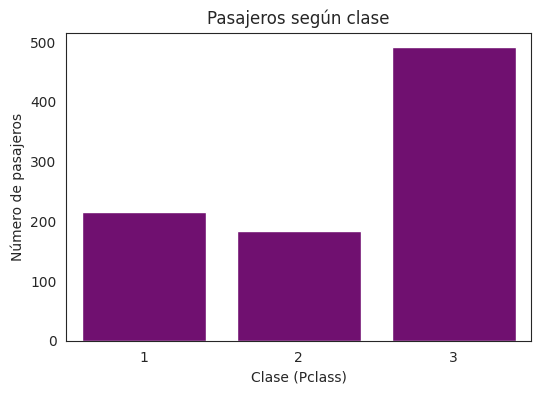

In [4]:
# Escriba aquí su código
plt.figure(figsize=(6,4))

sns.countplot(data=titanic, x="Pclass", color="purple")

plt.xlabel("Clase (Pclass)")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según clase")

plt.show()


La tercera clase (correspondiente a menores recursos) es la que contiene más pasajeros, y la muestra no está balanceada, de hecho se puede ver que entre la primera y segunda clase no alcanzan igualar la cantidad de pasajeros de tercera clase.

**2. Explore la distribución de `Age` con un histograma.**

Pruebe, por ejemplo, con 15, 30 y 50 bins.

- ¿Qué edades son más frecuentes?
- ¿La distribución parece simétrica?
- ¿El número de bins cambia su interpretación?


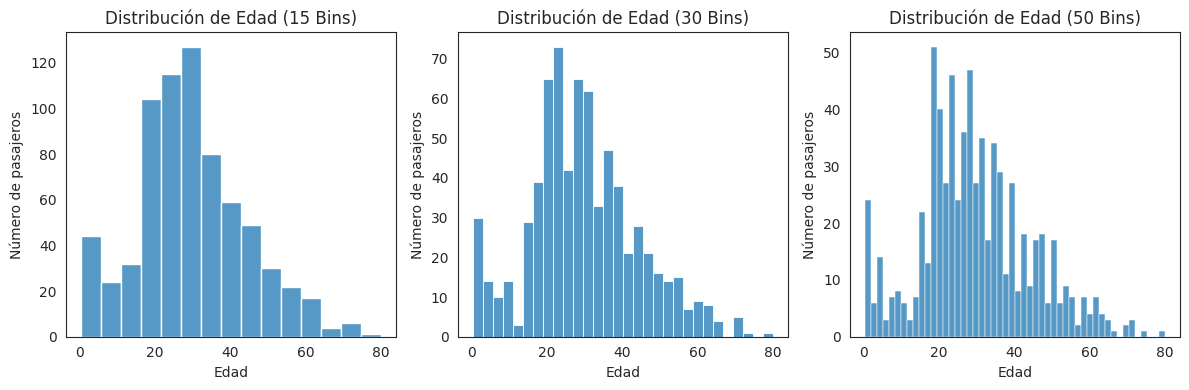

In [5]:
# Escriba aquí su código
# sns.histplot(...)
#para hacer más graficos
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

#ax=axes para cada gráfico

sns.histplot(titanic["Age"], bins=15, ax=axes[0])  #cambio los bins para ver la diferencia entra cada uno

sns.histplot(titanic["Age"], bins=30, ax=axes[1])

sns.histplot(titanic["Age"], bins=50, ax=axes[2])

#Nombro cada eje para cada gráfico y le doy titúlo a cada uno
axes[0].set_ylabel("Número de pasajeros")
axes[0].set_xlabel("Edad")
axes[0].set_title('Distribución de Edad (15 Bins)')
axes[1].set_ylabel("Número de pasajeros")
axes[1].set_xlabel("Edad")
axes[1].set_title('Distribución de Edad (30 Bins)')
axes[2].set_ylabel("Número de pasajeros")
axes[2].set_xlabel("Edad")
axes[2].set_title('Distribución de Edad (50 Bins)')

plt.tight_layout()
plt.show()


Las edades más frecuentes son alrededor de los 20 años, el intervalo entre 20 y 40 es el más grande. Considerando que la muestra va de 0 a 80, no se ve simetrica, tiende a concentrarce a la derecha.

La primera interpretación fue ver una concentracion entre 20 a 40, lo que no es erroneo, pero al aumentar la cantidad de bins, se logra apreciar las fluctuaciones entre el intervalo, demostrando que no todo el intervalo se distribuye de igual forma.

**3. Explore la distribución de `Fare`.**

Puede usar un histograma o un boxplot.

- ¿La distribución es simétrica?
- ¿Existen tarifas muy superiores al resto?
- ¿Qué podría significar esto?


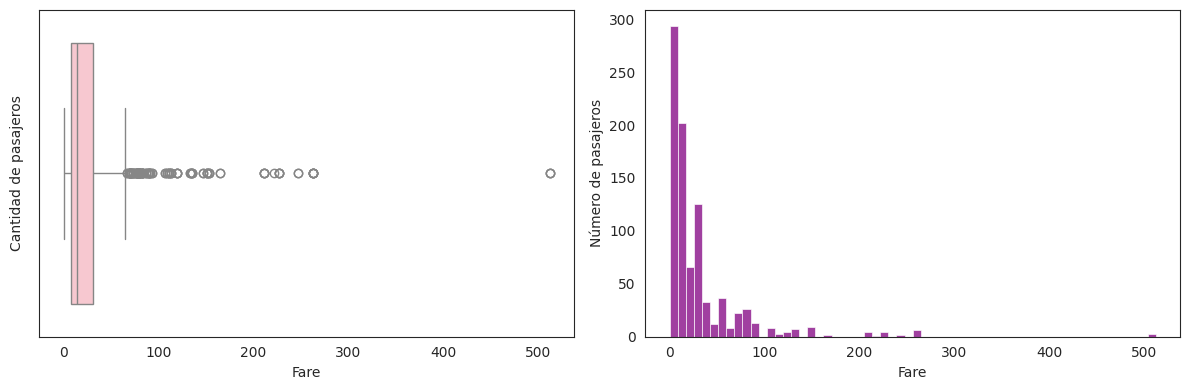

In [6]:
#Para 2 figuras
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

#axes[número de gráfico] para cada gráfico
sns.boxplot(data=titanic, x="Fare", color="Pink", ax=axes[0])   #axe0 gráfico 0

# Usamos corchetes axes[1]
sns.histplot(titanic["Fare"], bins=60, ax=axes[1], color="Purple")   #axe1 gráfico 1

# set_xlabel para cada eje segun el axe del gráfico
axes[1].set_ylabel("Número de pasajeros")
axes[1].set_xlabel("Fare")
axes[0].set_ylabel("Cantidad de pasajeros")
axes[0].set_xlabel("Fare")

plt.tight_layout()
plt.show()

La distribución es asimetrica, al estar sesgada a la derecha. Existen tarifas significativamente superiores al resto, esto se aprecia mejor en el Boxplot, los puntos grises que se salen de la norma (box) o mejor llamados outliers.

Considerando el gráfico de clases, que nos decía que existía una mayor cantidad de pasajeros en tercera clase, podemos ver la brecha social que se presentó dentro del crucero, concentrando cantidad en la tercera clase con pasajes alrededor de 50 libras, y un grupo cerrado de pasajeros de primera clase con pasajes de hasta 500 libras.

# Parte 2: Calidad de los datos

## ¿Qué información falta y por qué podría importar?

Antes de interpretar cualquier patrón debemos revisar la calidad de los datos.

Nos interesa detectar:

- valores faltantes
- características con mucha información incompleta
- valores extremos o sospechosos
- decisiones de limpieza que puedan cambiar nuestras conclusiones


In [7]:
datos_faltantes = titanic.isnull().sum()
datos_faltantes = datos_faltantes[datos_faltantes > 0]  #los datos que sean mayor a 0?

datos_faltantes


,0
Age,177
Cabin,687
Embarked,2


### Ejemplo de gráfico: valores faltantes

Podemos visualizar cuántos datos faltan en cada característica.


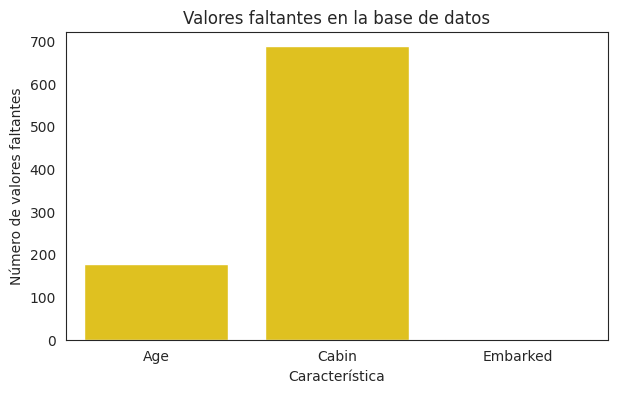

In [8]:
faltantes = datos_faltantes[datos_faltantes > 0]

plt.figure(figsize=(7,4))

sns.barplot(x=faltantes.index, y=faltantes.values, color='gold')

plt.xlabel("Característica")
plt.ylabel("Número de valores faltantes")
plt.title("Valores faltantes en la base de datos")

plt.show()


### Ahora usted

Observe especialmente `Age`, `Cabin` y `Embarked`.

**1. Compare la media y la mediana de `Age`.**

- Son similares?
- Es la media una buena representación de una edad típica?


In [9]:
mean_age = titanic["Age"].mean()
median_age = titanic["Age"].median()

print(f"Media de Edad: {mean_age:.2f}")
print(f"Mediana de Edad: {median_age:.2f}")

Media de Edad: 29.70
Mediana de Edad: 28.00


Son bastante parecidos, pero considerando que falta una cantidad de datos de edad, la media no es del todo confiable considerando que esta es sensible a datos extremos, en el caso que dentro del grupo de datos faltantes fuera datos que se escaparan de la media, esta podria cambiar.

**2. La edad tiene datos faltantes.**

- Le parece razonable reemplazar todas las edades faltantes por la media?
- Qué problema podría producir esa decisión en la distribución de edades?
- Qué otra estrategia consideraría?


No me parece razonable por el mismo argumento anterior. Ademas rellenar los datos con la media, generaria en mis gráficos deformaciones falsas, como picks en cantidades no reales generando posibles malos analisis, es decir cambiaria mi distribución y mis conclusiones.

Una estrategia podria ser generar datos a partir de otros valores, como por ejemplo la clase, asumiendo que gente de primera clase tiene una mayor edad. Tambén se podria usar la familia, si tiene hijos, hermanos o padres ayudaria a ver el rango de edad en el que se encuentra, esto podria ayudar a rellenar los datos sin generar diferencias reales.

**3. `Cabin` tiene una gran cantidad de valores faltantes.**

- Intentaría rellenarlos?
- Eliminaría la característica?
- Podría el hecho de conocer o no la cabina contener información por sí mismo?

No hay una única respuesta correcta: justifique su decisión.


Considerando que la pregunta guia es ver como se relacionan las caracteristicas con la supervivencia, conocer la cabina no parece del todo importante, a no ser que se sepa la localización de esta, como no tenemos esos datos, conocer la cabina en la que se encuentra parece innecesario. Ya que se tiene la informacion del valor del pasaje se puede hacer un analisis de la distribución de pasajeros dentro del crucero, y desde ahí llegar a la misma conclusión, por lo que yo no trataría de rellenarlos, sin embargo los mantendria para conocer mejor la distribución.

**4. `Embarked` tiene pocos datos faltantes.**

- Qué estrategia simple usaría en este caso?
- Por qué el tratamiento puede ser distinto al de `Cabin`?


Ya que tiene poco datos faltantes encuentro inecesario hacer algún cambio al grupo de datos. A diferencia de cabin, conocer donde se embarcaron puede ser más importante considerando que este dato puede cambiar según los recursos del pasajero.

# Parte 3: Explorar relaciones entre características

## ¿Cómo se relacionan las características de los pasajeros?

Después de estudiar las características individualmente, podemos comenzar a buscar estructura en los datos.

Preguntas posibles:

- La tarifa pagada está relacionada con la clase?
- Las edades son similares en todas las clases?
- Quiénes viajaban acompañados?
- Hay características que contienen información parcialmente similar?



### Ejemplo de gráfico: tarifa según clase

Un boxplot permite comparar la distribución de una característica numérica entre distintos grupos.


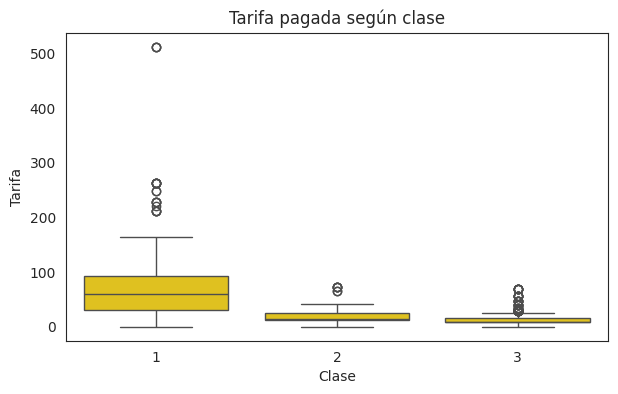

In [10]:
plt.figure(figsize=(7,4))

sns.boxplot(data=titanic, x="Pclass", y="Fare", color='gold')

plt.xlabel("Clase")
plt.ylabel("Tarifa")
plt.title("Tarifa pagada según clase")

plt.show()


### Preguntas

- La tarifa parece estar relacionada con la clase?
- Hay dispersión dentro de cada clase?
- Existen valores extremos?
- Diría que `Fare` y `Pclass` contienen exactamente la misma información?


La tarifa si se ve relacionada con la clase, por la dispersión se puede ver como se concentran los datos más para la tercera clase lo que quiere decir que los boletos no se diferenciaban en su mayoria, a diferencia que la primera clase donde se ven los datos extremos, existe una media, pero se ve que hay boletos que se salen significatibamente de la norma. No diría que Fare y Pclass tienen exactamente la misma información, de hecho al hacer los boxplot se puede ver como se distribuye o cambia la tarifa dentro de cada clase, aún así las conclusiones a las que se puede llegar a partir de ambos datos son parecidas, es decir ambas variables solo refuerzan posibles conslusiones.

### Ahora usted

**1. Compare la distribución de edad entre las tres clases.**

Use un gráfico que permita comparar las distribuciones.

- Los pasajeros tienen edades similares en todas las clases?
- Qué diferencias observa?


Text(0.5, 1.0, 'Edad según clase')

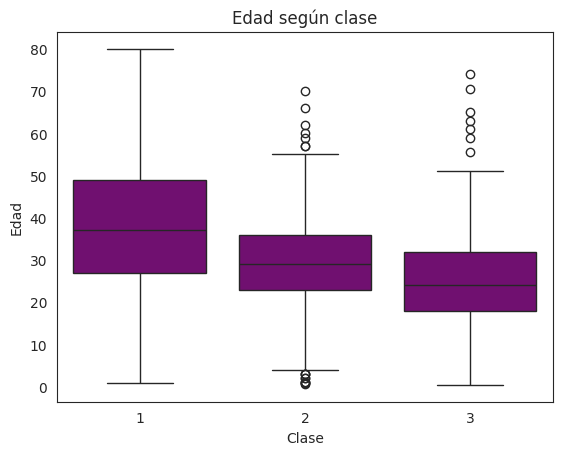

In [11]:
# Escriba aquí su código
# sns.boxplot(...)
sns.boxplot(data=titanic, x="Pclass", y="Age", color='Purple')

plt.xlabel("Clase")
plt.ylabel("Edad")
plt.title("Edad según clase")

Aca se ve una diferencia mas marcada entre clases, tal como asumi anteriormente la primera clase tiene edades mayores mientras que la tercera clase concentra pasajeros jovenes. Al ver los 3 boxplot al mismo tiempo se observa de mucha mejor manera como se diferencia la norma entre cada uno. Algo interesante es que la tercera clase tiene mas outliers que el resto, es decir su concentración es mucho mayor, mientras que la primera clase se distribuye mejor.


**2. Las características `SibSp` y `Parch` contienen información sobre familiares a bordo.**

Construya una nueva característica llamada `Familia`, que represente el número total de personas del grupo familiar incluyendo al propio pasajero:

\[
Familia = SibSp + Parch + 1
\]


In [12]:
# Complete el código

titanic["Familia"] = titanic["SibSp"] + titanic["Parch"] +1

print(titanic["Familia"].value_counts())


Familia
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64


**3. Explore la nueva característica `Familia`.**

- La mayoría de los pasajeros viajaba sola o acompañada?
- Hay grupos familiares muy grandes?
- Cambiaría su interpretación si solo mirara `SibSp` o `Parch` por separado?


La mayoria de pasajeros viajó solo, y si hay grupos familiares muy grandes con 5,7 y hasta 11 personas dentro del mimso grupo familiar. Si cambia la interpretación, ya que ahora se puede ver el grupo familiar completo, al contrario de ver solo los hermanos por ejemplo, que se formarian grupos más pequeños.

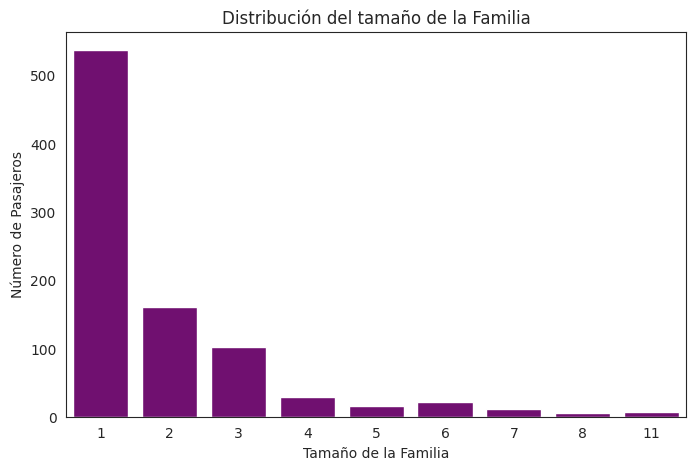

In [13]:

plt.figure(figsize=(8, 5))
sns.countplot(data=titanic, x='Familia', color="purple")

plt.title('Distribución del tamaño de la Familia')
plt.xlabel('Tamaño de la Familia')
plt.ylabel('Número de Pasajeros')
plt.show()

# Parte 4: Investigar la supervivencia

## ¿Qué características estaban asociadas con la supervivencia?

Ahora incorporaremos `Survived`, la variable que queremos comprender.

Investigaremos si la supervivencia está asociada con características como:

- sexo
- clase
- edad
- tamaño del grupo familiar


### Ejemplo de gráfico: supervivencia según sexo

Como `Survived` toma valores 0 y 1, su promedio dentro de un grupo corresponde a la **fracción de pasajeros que sobrevivió**.

`seaborn.barplot` calcula por defecto la media de la variable del eje vertical.


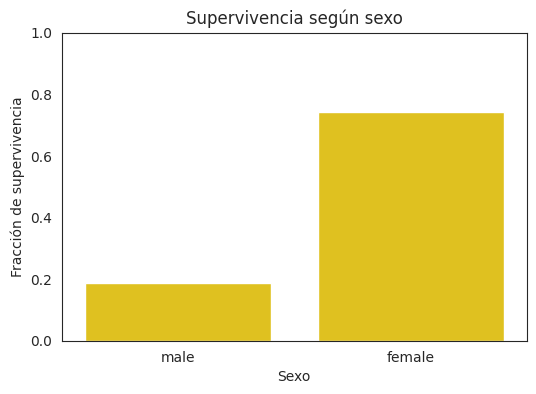

In [14]:
plt.figure(figsize=(6,4))

sns.barplot(data=titanic, x="Sex", y="Survived", errorbar=None, color='gold')

plt.xlabel("Sexo")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según sexo")
plt.ylim(0,1)

plt.show()


### Preguntas

- La fracción de supervivencia es similar para hombres y mujeres?
- Podemos concluir a partir de este gráfico por qué existe la diferencia?


La fracción no es similiar según el sexo, de acá se concluye que sobrevivieron más mujeres. Las conclusiones que se pueden sacar de este gráfico son simples suposiciones, pero que podrian ayudar a ver la realidad del caso, la razón más lógica viene del conocimiento general, al saber que al evacuar se priorizó mujeres y niños, generando una mayor taza de supervivencia para las mujeres.

### Ahora usted

**1. Explore la supervivencia según `Pclass`.**

- Hay diferencias entre las tres clases?
- Existe una tendencia?


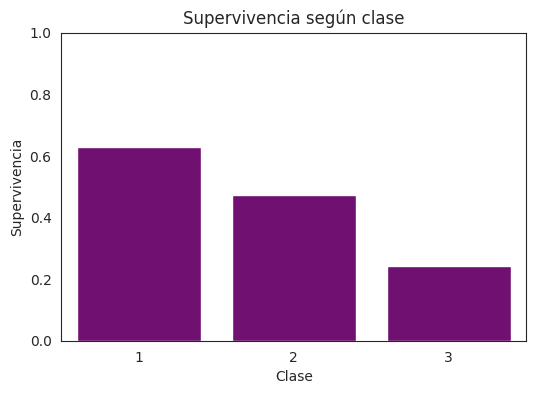

In [15]:
# Escriba aquí su código
plt.figure(figsize=(6,4))

sns.barplot(data=titanic, x="Pclass", y="Survived", errorbar=None, color='purple')

plt.xlabel("Clase")
plt.ylabel("Supervivencia")
plt.title("Supervivencia según clase")
plt.ylim(0,1)

plt.show()

Efectivamente existe diferencia en las clases y una tendencia clara de disminusión hacia la tercera clase. Es decir la 1ra clase obtuvo una mayor fracción de supervivencia respecto a la 2da y 3ra clase, siendo esta última la menor.

**2. Explore la supervivencia según edad.**

Puede comparar las distribuciones de edad de quienes sobrevivieron y quienes no sobrevivieron.

- La edad parece estar asociada con supervivencia?
- Hay algún grupo de edad que llame particularmente su atención?


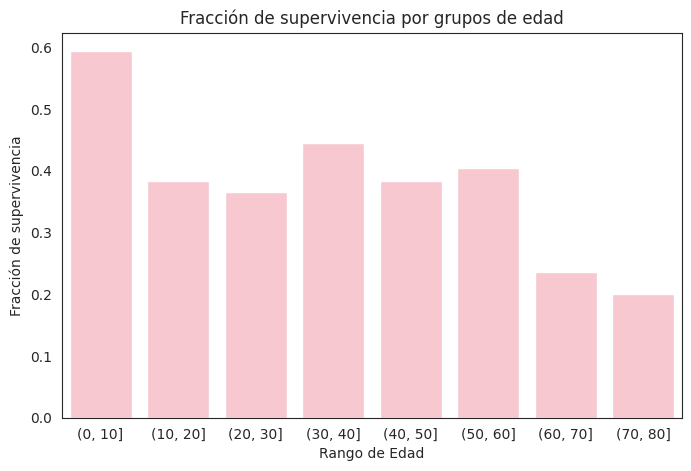

In [16]:
# Escriba aquí su código
#Para seguir usando el barplot, agrupo las edades usando pd.cut y las agrupamos en una nueva columna
titanic['Grupo_Edad'] = pd.cut(titanic['Age'], bins=range(0, 90, 10))

plt.figure(figsize=(8,5))

sns.barplot(data=titanic, x="Grupo_Edad", y="Survived", color="pink", errorbar=None)

plt.xlabel("Rango de Edad")
plt.ylabel("Fracción de supervivencia")
plt.title("Fracción de supervivencia por grupos de edad")

plt.show()

La edad no parece estár del todo asocuiada a la supervivencia, aunque los extremos si parecen mostrar una tendencia, los menores de hasta 10 años tuvieron una mayor fracción de supervivencia, mientras que los mayores de 60 a 80 tuvieron menor fracción de supervivencia,

**3. Explore la supervivencia según `Familia`.**

- Viajar solo parece favorable o desfavorable?
- La relación parece simple?
- Qué ocurre con los grupos familiares grandes?


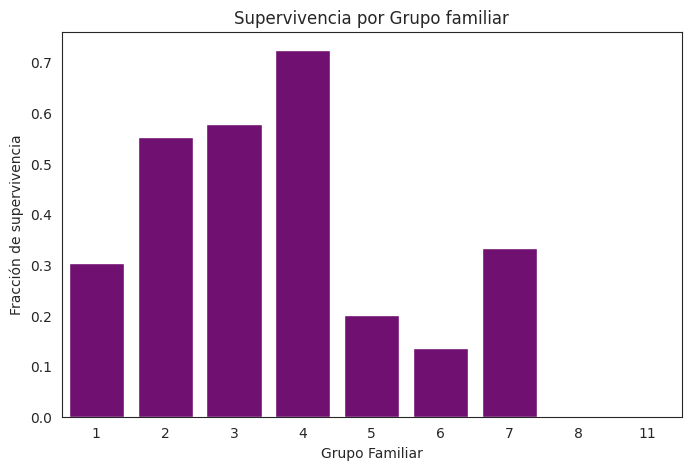

In [17]:
# Escriba aquí su código
plt.figure(figsize=(8,5))

sns.barplot(data=titanic, x="Familia", y="Survived", color="purple", errorbar=None)

plt.xlabel("Grupo Familiar")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia por Grupo familiar")

plt.show()


Viajar solo no se ve ni favorable ni desfavorable, el gráfico no muestra una tendencia clara en los grupos familiares exceptuando los grupos de familia mayores, ya que se observa que grupos de 8 o 11 personas no sobrevivieron.

De todas formas los grupos pequeños, de 2 a 4 tuvieron un mayor indice de supervivencia.

# Parte 5: Agregar contexto

## ¿Cambia una relación cuando consideramos otra característica?

Una relación global puede esconder comportamientos diferentes dentro de la muestra.

Ya estudiamos por separado:

- `Pclass` y supervivencia
- `Sex` y supervivencia

Ahora podemos preguntar:
 **¿La relación entre clase y supervivencia es igual para hombres y mujeres?**

Esta es una forma sencilla de análisis multivariado: consideramos varias características al mismo tiempo.


### Ejemplo de gráfico: clase, sexo y supervivencia


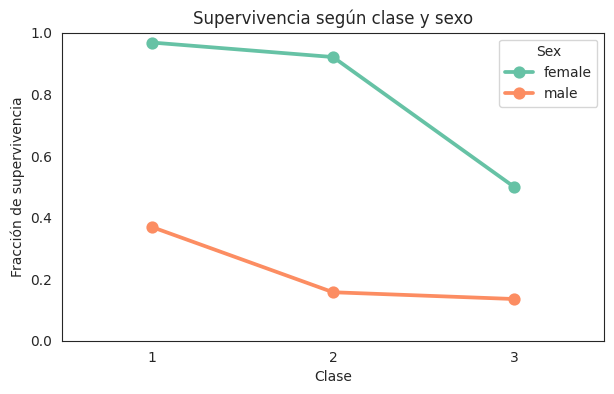

In [18]:
plt.figure(figsize=(7,4))

sns.pointplot(data=titanic,
              x="Pclass",
              y="Survived",
              hue="Sex",
              palette="Set2",
              errorbar=None)

plt.xlabel("Clase")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según clase y sexo")
plt.ylim(0,1)

plt.show()


### Preguntas sobre el ejemplo

- La relación entre clase y supervivencia es igual para hombres y mujeres?
- Qué información se perdía cuando mirábamos solamente `Pclass`?
- Qué información se perdía cuando mirábamos solamente `Sex`?
- Hay algún grupo particularmente favorecido o desfavorecido?



No, la relación no es la misma, para las mujeres el cambio entre 1ra y 2da clase no fue mucho pero en la 3ra clase cae abruptamente, a diferencia de los hombres que se mantiene entre 2da y 3ra clase y la caida se encuentra entre la 1ra y la 2da. Cuando mirabamos las variables por separado, se perdía la información de la otra, por ejemplo, establecimos que una mujer tuvo más probabilidades de sobrevivir, pero si ahora agregamos la desigualdad social, vemos que entre un hombre se primera clase y una mujer de 3ra clase no hay tanta diferencia. Las mujeres de primera clase están significativamente favorecidas, básicamente la fracción de supervivencia es casi 1, es decir la mayoria por no decir todas sobrevivieron.


### Ahora usted

**1. Cree una característica `Persona` con tres categorías:**

- `mujer`
- `hombre`
- `niño/a`

Considere como niño/a a un pasajero menor de 16 años.


In [19]:

titanic["Persona"] = titanic["Sex"].map({"male": "hombre", "female": "mujer"})

titanic.loc[titanic["Age"] < 16, "Persona"] = "niño/a" #niño menor a 16


titanic["Persona"].value_counts()



,count
Persona,
hombre,537
mujer,271
niño/a,83


**2. Explore la supervivencia según `Persona` y `Pclass`.**

- Los niños presentan el mismo patrón que los adultos?
- La clase sigue siendo importante dentro de cada grupo?
- Qué combinación de características parece asociarse con la mayor supervivencia?


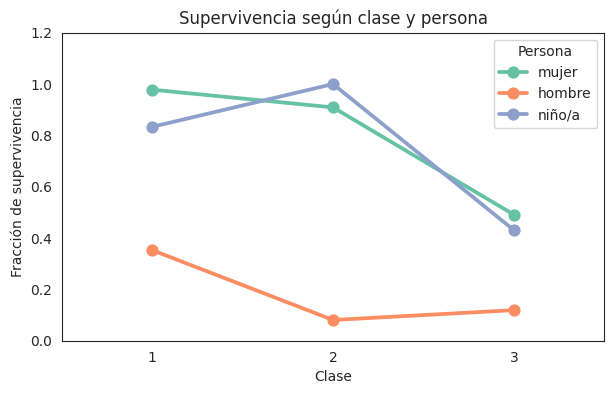

In [20]:
# Escriba aquí su código
plt.figure(figsize=(7,4))

sns.pointplot(data=titanic,
              x="Pclass",
              y="Survived",
              hue="Persona",
              palette="Set2",
              errorbar=None)

plt.xlabel("Clase")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según clase y persona")
plt.ylim(0,1.2)

plt.show()


Los niños no presentan el mismo patron que los adultos, aunque sigue tendiendo a decrecer para la tercera clase, vemos un aumento desde la 1ra a 2da clase, algo que ni hombres ni mujeres mostraba. Aún así la primera clase en promedio sigue mostrando un mejor nivel de supervivencia para cualquier persona. Además ahora el grupo con mayor supervivencia son los niños de 2da clase.

**3. Elija una relación adicional para explorar incorporando una tercera característica.**

Algunas ideas:

- edad + sexo + supervivencia;
- tamaño de familia + clase + supervivencia;
- puerto de embarque + clase + supervivencia.

No necesita crear una figura complicada. El objetivo es responder una pregunta concreta.

**Escriba primero la pregunta que quiere investigar y luego construya el gráfico.**


Object `supervivencia` not found.


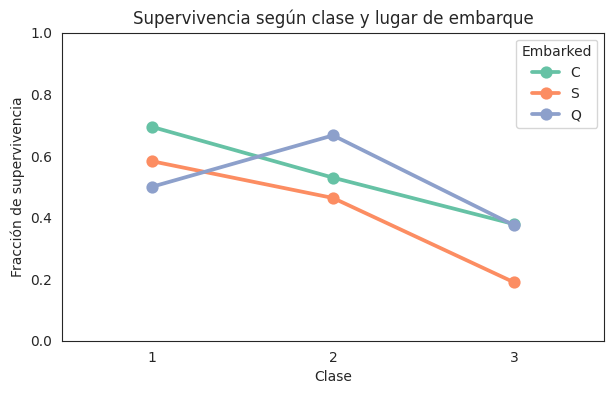

In [21]:
# Pregunta:

¿Existe relación entre el puerto de embarque la clase y la supervivencia?

# Código:
plt.figure(figsize=(7,4))

sns.pointplot(data=titanic,
              x="Pclass",
              y="Survived",
              hue="Embarked",
              palette="Set2",
              errorbar=None)

plt.xlabel("Clase")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según clase y lugar de embarque")
plt.ylim(0,1)


plt.show()


# Parte 6: Conclusión

## ¿Qué podemos concluir?

El EDA no termina cuando encontramos diferencias entre grupos.

Queremos distinguir entre:

### Observación
Algo que vemos directamente en los datos.

### Interpretación
Cómo describimos ese patrón.

### Hipótesis
Una explicación posible que debería ser evaluada con más información.

Por ejemplo:

> **Observación:** las mujeres presentan una mayor fracción de supervivencia que los hombres.

- **Podemos concluir, solo a partir de esta base de datos, que durante la evacuación se dio prioridad a mujeres y niños?**
- **Qué información adicional necesitaríamos para evaluar esa hipótesis?**
- **Qué otras explicaciones podrían producir el mismo patrón de supervivencia?**

## Síntesis del análisis

Revise todas las figuras construidas y responda:

### 1. Quiénes eran los pasajeros del Titanic?

Describa brevemente la muestra considerando, al menos:

- sexo
- clase
- edad
- tamaño de familia.


### 2. Qué características estaban asociadas con la supervivencia?

Considere:

- sexo
- clase
- edad
- viajar solo o acompañado.



### 3. Qué relaciones cambiaron al considerar varias características al mismo tiempo?

Use como ejemplo al menos uno de los análisis multivariados realizados.


### 4. Encontró características que contienen información relacionada?

Explique al menos un caso.


### 5. Qué resultado le pareció más inesperado?

Proponga una posible explicación, dejando claro qué parte corresponde a una observación y qué parte corresponde a una hipótesis.


Los pasajeros del titanic en promedio eran personas de clase baja alrededor de los 20 años, en familias pequeñas o sin familia y en su mayoria mujeres.

La supervivencia se asoció de manera significativa con el sexo y la clase, siendo mujeres de 1ra clase ampliamente favorecidos, en una menor cantidad, los niños.

La supervivencia de mujeres y hombres, al considerar también la clase se observó que también importó el grupo social al que perteneciá un pasajero.

La clase y la tarifa están fuertemente relacionadas, ya que al pertenecer a una clase acomodada el costo de los pasajes sube.

La supervivencia por grupo familiar me pareció interesante, uno pensaría que al ir solo en un viaje tu probabilidad de sobrevivir es mayor por no tener preocupaciones aparte, pero el gráfico no lo mostró así, se observa que los pasajeros pertenecientes a grupos familiares tuvieron una mejor supervivencia. Mi hipotesis dice que esto pudo deberse a la red de apoyo con la que contaban, tener un hermano o tus 2 padres junto a ti disminuye las dificultades. Aunque si esto se lleva a un extremo (familias de 11) se vuelve un problema.

# Conclusión final

## ¿Cuál es el perfil del pasajero típico que sobrevivió?

A partir de **sus propios resultados**, escriba una conclusión breve que caracterice al pasajero con mayor probabilidad de haber sobrevivido en esta muestra.

Considere, cuando corresponda:

- sexo
- edad
- clase
- tamaño del grupo familiar
- otras características que hayan resultado relevantes

Su respuesta debe estar respaldada por las figuras que construyó.


### Escriba aquí su conclusión

**El pasajero típico que sobrevivió...**

Basandome en lo gráficos construidos, el perfil de un sobreviviente es una mujer, perteneciente a 1ra clase, esto se ve perfectamente en el primer gráfico multivariado. Respecto a la edad, tener elrededor de 20 años o estar en un rango infantil de hasta 10 años. Por último viajar con una familia pequeña de entre 2 a 4, las probabilidades se maximizan.

Ademas haber embarcado en Cherbourg (C), representó una leve ventaja.